# Day 3 — Tiny CIFAR-10 CNN

Follow the official PyTorch CIFAR-10 tutorial, keeping classification as a small learning vehicle.


## Load and normalize CIFAR-10

Source: this section follows the official PyTorch CIFAR-10 tutorial's first step: load and normalize the CIFAR-10 training and test datasets using `torchvision`.

`torchvision.transforms.v2` is the newer torchvision transform API. In this notebook it is imported as `v2`, so names like `v2.Compose` and `v2.Normalize` come from that API.

`v2.Compose([...])` is an ordered recipe. It sends each image through the listed transforms from top to bottom, so the output of one step becomes the input to the next step.

The transform pipeline is:

1. `v2.ToImage()` converts the loaded CIFAR-10 image into torchvision/PyTorch image format. The CNN needs tensor-like image data rather than a plain image object.
2. `v2.ToDtype(torch.float32, scale=True)` changes pixel values into floating-point numbers and scales them to about `0.0` through `1.0`. Neural networks train more predictably on small floating-point values than on raw integer pixel values.
3. `v2.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))` normalizes the red, green, and blue channels with `new_value = (old_value - mean) / std`. With mean `0.5` and standard deviation `0.5`, values near `0.0` become about `-1.0`, values near `0.5` become `0.0`, and values near `1.0` become about `1.0`.

We do these transformations because the model should see every image in a consistent numeric format, type, and scale. That makes the first training loop easier to reason about and gives the CNN a clean input signal from which to learn filters. Accuracy is only a sanity check here; the main reason to train this tiny classifier is to create learned feature maps we can inspect later.


In [90]:
import torch
import torchvision
from torchvision.transforms import v2

transform = v2.Compose(
    [
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ]
)

## Create project-relative CIFAR-10 datasets and DataLoaders

This section continues the official PyTorch CIFAR-10 tutorial's data-loading step. The tutorial uses `torchvision.datasets.CIFAR10` to create a training dataset and a test dataset, then wraps each dataset in a `torch.utils.data.DataLoader`.

A dataset knows how to return one example at a time: an image and its label. A DataLoader builds on top of a dataset and returns mini-batches, which are small groups of examples used by the training loop.

`train=True` selects the training split, and `train=False` selects the test split. `download=True` lets torchvision download the dataset if it is missing. `transform=transform` applies the preprocessing pipeline from the previous cell every time an image is loaded.


In [91]:
from pathlib import Path

current_dir: Path = Path.cwd()
PROJECT_ROOT: Path = next(
    (candidate for candidate in (current_dir, *current_dir.parents) if (candidate / "pyproject.toml").exists()),
    current_dir,
)
DATA_ROOT: Path = PROJECT_ROOT / "data"

print(f"Project root: {PROJECT_ROOT}")
print(f"CIFAR-10 data root: {DATA_ROOT}")

batch_size = 64
train_set = torchvision.datasets.CIFAR10(
    root=str(DATA_ROOT),
    train=True,
    download=True,
    transform=transform,
)

train_loader = torch.utils.data.DataLoader(
    train_set,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,  # Matches the official tutorial; use 0 only if Windows multiprocessing errors occur.
)

test_set = torchvision.datasets.CIFAR10(
    root=str(DATA_ROOT),
    train=False,
    download=True,
    transform=transform,
)

test_loader = torch.utils.data.DataLoader(
    test_set,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
)

classes = (
    "plane",
    "car",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
)

Project root: C:\Users\giloz\dev\cnn-feature-map-lab
CIFAR-10 data root: C:\Users\giloz\dev\cnn-feature-map-lab\data


## Inspect one training batch

Before training, the official tutorial shows a few training images. This is a sanity check: we confirm that the DataLoader returns recognizable images and labels before asking the CNN to learn from them.

CIFAR-10 images are low-resolution by design. The originals are `3 x 32 x 32`, meaning 3 color channels, 32 pixels high, and 32 pixels wide. The preprocessing pipeline changes the image format, numeric type, and numeric range, but it does not resize the images.

`torchvision.utils.make_grid(images)` combines the mini-batch into one display image. The helper function `imshow` first unnormalizes the image with `img / 2 + 0.5`, because the model sees values near `[-1, 1]` but Matplotlib expects display values closer to `[0, 1]`.

PyTorch image tensors are usually channel-first: `[channels, height, width]`. Matplotlib expects channel-last: `[height, width, channels]`. That is why the display code uses `np.transpose(np_img, (1, 2, 0))`.

The printed class names come from `classes[labels[j]]`. Each numeric label is an index into the `classes` tuple, so a label like `3` becomes `cat`.


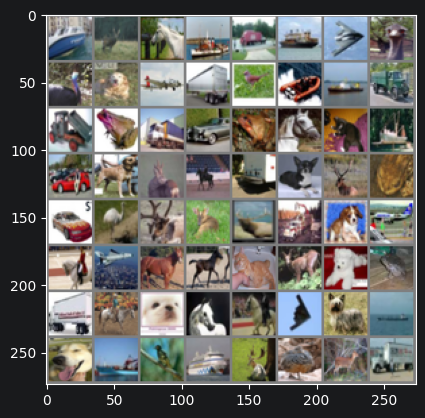

ship  deer  horse ship  truck ship  plane bird  bird  dog   plane truck bird  ship  ship  truck truck frog  truck car   frog  horse cat   ship  car   dog   deer  horse truck dog   deer  frog  car   bird  deer  deer  deer  truck dog   plane horse plane horse horse cat   deer  dog   frog  truck horse dog   horse horse plane dog   ship  dog   ship  bird  ship  deer  bird  deer  truck


In [92]:
import matplotlib.pyplot as plt
import numpy as np


def imshow(img: torch.Tensor) -> None:
    img = img / 2 + 0.5  # unnormalize from [-1, 1] back toward [0, 1]
    np_img = img.numpy()
    plt.imshow(np.transpose(np_img, (1, 2, 0)))
    plt.show()


data_iter = iter(train_loader)
images, labels = next(data_iter)

imshow(torchvision.utils.make_grid(images))
print(" ".join(f"{classes[labels[j]]:5s}" for j in range(batch_size)))

## Define a tiny CNN

This section follows the official PyTorch CIFAR-10 tutorial's second step: define a Convolutional Neural Network. The exact layer counts are tutorial choices, not universal CNN laws. For this lab, the important reason to build the model is to create learned convolution filters and feature maps that we can inspect later.

### Convolution layers

`conv1` and `conv2` are convolution layers. A convolution layer learns small filters that scan over the image and produce feature maps. `conv1 = nn.Conv2d(in_channels=3, out_channels=6, kernel_size=5)` accepts 3 input channels because CIFAR-10 images are RGB, creates 6 output feature maps, and uses 5 by 5 filters. `conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5)` accepts the 6 feature maps from `conv1` and creates 16 new feature maps.

Why use two convolution layers instead of one? The first convolution can learn simple local patterns such as color contrasts, edges, or corners. The second convolution sees those first feature maps rather than raw pixels, so it can combine simple responses into slightly richer visual patterns. Two convolution layers are not required for every model, but they give us a small feature hierarchy to inspect.

### Pooling and shape changes

`pool = nn.MaxPool2d(kernel_size=2, stride=2)` shrinks each feature map by keeping the strongest response in each 2 by 2 window. This makes the spatial size smaller while keeping strong activations. Starting from one CIFAR-10 image, the shape changes like this:

```text
input image:        3 x 32 x 32
conv1, kernel 5:    6 x 28 x 28
pool 2x2:           6 x 14 x 14
conv2, kernel 5:   16 x 10 x 10
pool 2x2:          16 x 5 x 5
flatten:           16 * 5 * 5 = 400 numbers
```

That is why `fc1` starts with `nn.Linear(in_features=16 * 5 * 5, out_features=120)`. Right before `fc1`, each image has 16 feature maps, and each feature map is 5 by 5. `torch.flatten(x, 1)` keeps the batch dimension and turns the remaining `16 x 5 x 5` values into one list of 400 numbers per image.

### Fully connected (`fc`) layers

`fc` stands for fully connected. In PyTorch these are `nn.Linear` layers. They are called fully connected because each output number can use all input numbers from the previous layer.

The tutorial uses three fully connected layers: `400 -> 120 -> 84 -> 10`. The final `10` means one raw score for each CIFAR-10 class. We could use a simpler head such as `nn.Linear(in_features=16 * 5 * 5, out_features=10)`, which would map the 400 flattened feature values directly to 10 class scores. The tutorial's extra hidden layers give the model more chances to mix the learned visual features before producing class scores, but they are not the main focus of this lab.

### ReLU activations

`F.relu(...)` applies the ReLU activation function: `relu(x) = max(0, x)`. Negative values become 0, and positive values stay positive. After a convolution, this turns raw filter responses into a simpler signal: the feature either did not fire much, or it fired positively.

We apply ReLU after `conv1`, `conv2`, `fc1`, and `fc2` because stacked linear operations without activations would behave too much like one large linear operation. ReLU adds a nonlinear step, which lets later layers build more flexible combinations of features. The final layer `fc3` does not use ReLU here because it returns raw class scores, called logits, and `CrossEntropyLoss` expects those raw scores.


In [93]:
import torch.nn as nn
import torch.nn.functional as F


class Net(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=6, kernel_size=5)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5)
        self.fc1 = nn.Linear(in_features=16 * 5 * 5, out_features=120)
        self.fc2 = nn.Linear(in_features=120, out_features=84)
        self.fc3 = nn.Linear(in_features=84, out_features=10)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x is a 4 batch of 32 images, each 3 x 32 x 32 so shape is (4, 3, 32, 32)
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)  # flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


net = Net()
net

Net(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

## Trace shapes through the CNN

This section walks one mini-batch through the same steps used inside `forward`. Each code cell updates `x` once, then prints the shape so the size change is visible before moving on. Run these cells in order because each one depends on the `x` created by the previous cell.

### Input batch: `[batch, channels, height, width]`

The DataLoader returns a mini-batch of images. With `batch_size = 4`, CIFAR-10 gives `4` RGB images, so the starting shape is `[4, 3, 32, 32]`.

In [94]:
images, labels = next(iter(train_loader))

x = images
print("input:", x.shape)

input: torch.Size([64, 3, 32, 32])


### `conv1`: RGB image channels → 6 feature maps

`conv1` accepts `in_channels=3` because the input has red, green, and blue channels. It creates `out_channels=6` learned feature maps. The `5 x 5` kernel has no padding, so height and width shrink from `32` to `28`.

In [95]:
x = net.conv1(x)
print("after conv1:", x.shape)

after conv1: torch.Size([64, 6, 28, 28])


### `relu1`: keep positive filter responses

ReLU changes the values, not the shape. Negative responses become `0`, while positive responses stay positive.

In [96]:
x = F.relu(x)
print("after relu1:", x.shape)

after relu1: torch.Size([64, 6, 28, 28])


### `pool1`: shrink each feature map

The `2 x 2` max-pool with `stride=2` halves the spatial size. The number of feature maps stays `6`, while height and width go from `28` to `14`.

In [97]:
x = net.pool(x)
print("after pool1:", x.shape)

after pool1: torch.Size([64, 6, 14, 14])


### `conv2`: 6 feature maps → 16 feature maps

`conv2` reads the 6 feature maps from `conv1` and produces 16 new feature maps. The `5 x 5` kernel again shrinks height and width by 4, so `14` becomes `10`.

In [98]:
x = net.conv2(x)
print("after conv2:", x.shape)

after conv2: torch.Size([64, 16, 10, 10])


### `relu2`: activate the second set of feature maps

This ReLU again changes values but keeps the same shape. It turns the second convolution output into positive activation signals.

In [99]:
x = F.relu(x)
print("after relu2:", x.shape)

after relu2: torch.Size([64, 16, 10, 10])


### `pool2`: shrink to `16 x 5 x 5`

The second pool halves `10 x 10` feature maps into `5 x 5` feature maps. This is the shape that explains the `16 * 5 * 5` input size of `fc1`.

In [100]:
x = net.pool(x)
print("after pool2:", x.shape)

after pool2: torch.Size([64, 16, 5, 5])


### `flatten`: feature maps → one vector per image

`torch.flatten(x, 1)` keeps the batch dimension and flattens everything after it. Each image has `16 * 5 * 5 = 400` feature values, so the batch becomes `[4, 400]`.

In [101]:
x = torch.flatten(x, 1)
print("after flatten:", x.shape)

after flatten: torch.Size([64, 400])


### `fc1`: 400 feature values → 120 mixed features

`fc1` is fully connected, so each of its 120 outputs can use all 400 flattened feature values from one image.

In [102]:
x = net.fc1(x)
print("after fc1:", x.shape)

after fc1: torch.Size([64, 120])


### `relu3`: activate the first fully connected layer

This ReLU keeps the shape `[4, 120]` but changes negative values to `0`.

In [103]:
x = F.relu(x)
print("after relu3:", x.shape)

after relu3: torch.Size([64, 120])


### `fc2`: 120 mixed features → 84 mixed features

`fc2` gives the classifier head another chance to combine the feature evidence before the final class scores.

In [104]:
x = net.fc2(x)
print("after fc2:", x.shape)

after fc2: torch.Size([64, 84])


### `relu4`: activate the second fully connected layer

This ReLU keeps the shape `[4, 84]` and passes positive evidence forward.

In [105]:
x = F.relu(x)
print("after relu4:", x.shape)

after relu4: torch.Size([64, 84])


### `fc3`: 84 mixed features → 10 class scores

The final layer produces 10 raw scores per image, one for each CIFAR-10 class. These scores are logits, so we do not apply ReLU after this layer.

In [106]:
x = net.fc3(x)
print("after fc3:", x.shape)

after fc3: torch.Size([64, 10])


## Define loss, optimizer, and run one sanity-check batch

This section follows the official PyTorch CIFAR-10 tutorial's third step: define a loss function and an optimizer. The project-specific addition is `device`, which chooses `cuda:0` when CUDA is available and otherwise falls back to `cpu`.

`loss_fn = nn.CrossEntropyLoss()` compares the model's 10 raw class scores with the correct class label for each image. The output is one loss number: a smaller value means the current predictions are less wrong.

`optimizer = optim.SGD(...)` creates the object that will update the model's trainable weights. `lr=0.001` is the learning rate, meaning the update steps are intentionally small. `momentum=0.9` lets the optimizer keep some direction from recent updates, matching the official tutorial.

Before running a full training loop, this cell checks one mini-batch. The expected output shape is `[batch_size, 10]`: one row per image and 10 class scores per row. The expected label shape is `[batch_size]`: one correct class index per image. A first loss near `2.3` is normal for an untrained 10-class model because it is still close to guessing.


In [107]:
import torch.optim as optim

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
net = Net().to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

images, labels = next(iter(train_loader))
images, labels = images.to(device), labels.to(device)

outputs = net(images)
loss = loss_fn(outputs, labels)

print(f"device: {device}")
print(f"output shape: {outputs.shape}")
print(f"labels: {labels.shape}")
print(f"Loss: {loss.item():.4f}")

device: cuda:0
output shape: torch.Size([64, 10])
labels: torch.Size([64])
Loss: 2.3161


## Train the tiny CNN with mini-batch progress

This section adapts the official tutorial's training-loop pattern, with the added CUDA/CPU device transfer for each mini-batch. The goal is not to chase high classifier accuracy; the goal is to make the convolution filters learn enough from CIFAR-10 that their feature maps become meaningful to inspect later.

`net.train()` puts the model in training mode. Each loop iteration uses one mini-batch from `train_loader`: `optimizer.zero_grad()` clears old gradients, `outputs = net(images)` makes predictions, `loss = loss_fn(outputs, labels)` measures wrongness, `loss.backward()` computes gradients, and `optimizer.step()` updates the weights.

`running_loss` adds up mini-batch losses between progress prints. With `batch_size = 64`, CIFAR-10 has fewer than 2000 mini-batches per epoch, so this notebook prints every 100 mini-batches instead. `train_loss_history` keeps one average loss per epoch for checkpoint metadata.


In [108]:
num_epochs = 4
print_every = 100
train_loss_history = []

for epoch in range(num_epochs):
    net.train()
    running_loss = 0.0
    epoch_loss_total = 0.0

    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = net(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        batch_loss = loss.item()
        running_loss += batch_loss
        epoch_loss_total += batch_loss

        if i % print_every == print_every - 1:
            print(f"[{epoch + 1}, {i + 1:5d}] loss: {running_loss / print_every:.3f}")
            running_loss = 0.0

    epoch_loss = epoch_loss_total / len(train_loader)
    train_loss_history.append(epoch_loss)
    print(f"[{epoch + 1}] epoch loss: {epoch_loss:.3f}")

print("Finished Training")


[1,   100] loss: 2.303
[1,   200] loss: 2.303
[1,   300] loss: 2.302
[1,   400] loss: 2.301
[1,   500] loss: 2.299
[1,   600] loss: 2.297
[1,   700] loss: 2.294
[1] epoch loss: 2.299
[2,   100] loss: 2.283
[2,   200] loss: 2.269
[2,   300] loss: 2.240
[2,   400] loss: 2.192
[2,   500] loss: 2.140
[2,   600] loss: 2.094
[2,   700] loss: 2.051
[2] epoch loss: 2.166
[3,   100] loss: 2.040
[3,   200] loss: 2.007
[3,   300] loss: 1.956
[3,   400] loss: 1.952
[3,   500] loss: 1.947
[3,   600] loss: 1.912
[3,   700] loss: 1.915
[3] epoch loss: 1.955
[4,   100] loss: 1.864
[4,   200] loss: 1.849
[4,   300] loss: 1.845
[4,   400] loss: 1.822
[4,   500] loss: 1.805
[4,   600] loss: 1.780
[4,   700] loss: 1.757
[4] epoch loss: 1.811
Finished Training


## Save the learned weights

This section saves the trained model checkpoint under `models/`, matching the lab convention. A checkpoint is a file that stores the learned parameter values so later notebooks can reload the same trained CNN.

`net.state_dict()` contains the learned convolution filters, fully connected weights, and biases. The checkpoint also stores small pieces of training context such as `classes`, `batch_size`, `num_epochs`, and the training-loss history, so the saved file is easier to understand later.


In [109]:
MODELS_ROOT = PROJECT_ROOT / "models"
MODELS_ROOT.mkdir(exist_ok=True)

checkpoint_path = MODELS_ROOT / "tiny_cifar10_cnn.pth"

torch.save(
    {
        "model_state_dict": net.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "num_epochs": num_epochs,
        "classes": classes,
        "batch_size": batch_size,
        "print_every": print_every,
        "train_loss_history": train_loss_history,
        "final_train_loss": train_loss_history[-1] if train_loss_history else None,
    },
    checkpoint_path,
)

print(f"Saved checkpoint to: {checkpoint_path}")


Saved checkpoint to: C:\Users\giloz\dev\cnn-feature-map-lab\models\tiny_cifar10_cnn.pth


## Short training note

After rerunning the training cell, record the printed epoch losses here. The important evidence is that the average training loss moves downward across the short run, which shows the tiny CNN has started learning CIFAR-10 patterns. Accuracy is still only a sanity check for this lab; the main reason to train this classifier is to create learned feature maps for later visual inspection.
